# NSL-KDD Dataset Correlation Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen
import io

## Load Dataset from GitHub

In [3]:
# URL of the dataset
url = 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt'

# Load the dataset
df = pd.read_csv(url, header=None)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Dataset shape: (125973, 43)

First few rows:
   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]


## Load Column Names and Assign Headers

In [4]:
# Load column names from the Field Names CSV
field_names_url = 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/Field%20Names.csv'

# Load field names
field_names_df = pd.read_csv(field_names_url, header=None)
column_names = field_names_df[0].tolist()

print(f"Number of column names from CSV: {len(column_names)}")
print(f"Number of columns in dataframe: {df.shape[1]}")
print(f"Difference: {df.shape[1] - len(column_names)}")

# The NSL-KDD dataset has 2 additional columns: attack_type and difficulty_level
# Add these to the column names
if df.shape[1] > len(column_names):
    column_names.extend(['attack_type', 'difficulty_level'])

print(f"\nTotal column names after adjustment: {len(column_names)}")
print(f"\nColumn Names:")
for i, name in enumerate(column_names):
    print(f"{i}: {name}")

# Assign column names to the dataframe
df.columns = column_names

print(f"\n\nDataframe with column headers:")
print(df.head())

Number of column names from CSV: 41
Number of columns in dataframe: 43
Difference: 2

Total column names after adjustment: 43

Column Names:
0: duration
1: protocol_type
2: service
3: flag
4: src_bytes
5: dst_bytes
6: land
7: wrong_fragment
8: urgent
9: hot
10: num_failed_logins
11: logged_in
12: num_compromised
13: root_shell
14: su_attempted
15: num_root
16: num_file_creations
17: num_shells
18: num_access_files
19: num_outbound_cmds
20: is_host_login
21: is_guest_login
22: count
23: srv_count
24: serror_rate
25: srv_serror_rate
26: rerror_rate
27: srv_rerror_rate
28: same_srv_rate
29: diff_srv_rate
30: srv_diff_host_rate
31: dst_host_count
32: dst_host_srv_count
33: dst_host_same_srv_rate
34: dst_host_diff_srv_rate
35: dst_host_same_src_port_rate
36: dst_host_srv_diff_host_rate
37: dst_host_serror_rate
38: dst_host_srv_serror_rate
39: dst_host_rerror_rate
40: dst_host_srv_rerror_rate
41: attack_type
42: difficulty_level


Dataframe with column headers:
   duration protocol_type   se

In [5]:
# Identify categorical and numerical columns
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("="*80)
print("COLUMN TYPE ANALYSIS")
print("="*80)

print(f"\n\nNUMERICAL COLUMNS ({len(numerical_columns)}):")
print("-" * 80)
for i, col in enumerate(numerical_columns, 1):
    print(f"{i:2d}. {col}")

print(f"\n\nCATEGORICAL COLUMNS ({len(categorical_columns)}):")
print("-" * 80)
for i, col in enumerate(categorical_columns, 1):
    print(f"{i:2d}. {col}")

print(f"\n\nSUMMARY:")
print(f"Total columns: {len(df.columns)}")
print(f"Numerical columns: {len(numerical_columns)}")
print(f"Categorical columns: {len(categorical_columns)}")

# Create a summary dataframe
column_info = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Type': ['Numerical' if col in numerical_columns else 'Categorical' for col in df.columns]
})

print("\n\nDetailed Column Information:")
print(column_info.to_string(index=False))

COLUMN TYPE ANALYSIS


NUMERICAL COLUMNS (39):
--------------------------------------------------------------------------------
 1. duration
 2. src_bytes
 3. dst_bytes
 4. land
 5. wrong_fragment
 6. urgent
 7. hot
 8. num_failed_logins
 9. logged_in
10. num_compromised
11. root_shell
12. su_attempted
13. num_root
14. num_file_creations
15. num_shells
16. num_access_files
17. num_outbound_cmds
18. is_host_login
19. is_guest_login
20. count
21. srv_count
22. serror_rate
23. srv_serror_rate
24. rerror_rate
25. srv_rerror_rate
26. same_srv_rate
27. diff_srv_rate
28. srv_diff_host_rate
29. dst_host_count
30. dst_host_srv_count
31. dst_host_same_srv_rate
32. dst_host_diff_srv_rate
33. dst_host_same_src_port_rate
34. dst_host_srv_diff_host_rate
35. dst_host_serror_rate
36. dst_host_srv_serror_rate
37. dst_host_rerror_rate
38. dst_host_srv_rerror_rate
39. difficulty_level


CATEGORICAL COLUMNS (4):
--------------------------------------------------------------------------------
 1. protocol_

In [6]:
# Quick summary visualization
print("\n" + "="*80)
print("COLUMN CLASSIFICATION SUMMARY")
print("="*80)

print(f"\n✓ CATEGORICAL COLUMNS ({len(categorical_columns)}):")
for col in categorical_columns:
    unique_vals = df[col].nunique()
    print(f"   • {col} ({unique_vals} unique values)")

print(f"\n✓ NUMERICAL COLUMNS ({len(numerical_columns)}):")
for col in numerical_columns:
    print(f"   • {col}")

print(f"\n{'─'*80}")
print(f"Total: {len(df.columns)} columns | Categorical: {len(categorical_columns)} | Numerical: {len(numerical_columns)}")
print("="*80)


COLUMN CLASSIFICATION SUMMARY

✓ CATEGORICAL COLUMNS (4):
   • protocol_type (3 unique values)
   • service (70 unique values)
   • flag (11 unique values)
   • attack_type (23 unique values)

✓ NUMERICAL COLUMNS (39):
   • duration
   • src_bytes
   • dst_bytes
   • land
   • wrong_fragment
   • urgent
   • hot
   • num_failed_logins
   • logged_in
   • num_compromised
   • root_shell
   • su_attempted
   • num_root
   • num_file_creations
   • num_shells
   • num_access_files
   • num_outbound_cmds
   • is_host_login
   • is_guest_login
   • count
   • srv_count
   • serror_rate
   • srv_serror_rate
   • rerror_rate
   • srv_rerror_rate
   • same_srv_rate
   • diff_srv_rate
   • srv_diff_host_rate
   • dst_host_count
   • dst_host_srv_count
   • dst_host_same_srv_rate
   • dst_host_diff_srv_rate
   • dst_host_same_src_port_rate
   • dst_host_srv_diff_host_rate
   • dst_host_serror_rate
   • dst_host_srv_serror_rate
   • dst_host_rerror_rate
   • dst_host_srv_rerror_rate
   • difficu

## Data Information

In [7]:
# Display dataset info
print("Dataset Info:")
print(df.info())
print(f"\nDataset Description:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null

## Data Preprocessing and Trend Analysis

This section performs practical preprocessing checks before modeling and visualizes important data trends.


In [ ]:
# Data quality checks and preprocessing
print('='*90)
print('DATA PREPROCESSING SUMMARY')
print('='*90)

rows_before = df.shape[0]
missing_counts = df.isna().sum()
total_missing = int(missing_counts.sum())
duplicate_rows = int(df.duplicated().sum())

print(f'Rows before preprocessing: {rows_before:,}')
print(f'Total missing values: {total_missing:,}')
print(f'Duplicate rows: {duplicate_rows:,}')

if total_missing > 0:
    print('\nMissing value handling:')
    for col in df.columns:
        if df[col].isna().sum() > 0:
            if pd.api.types.is_numeric_dtype(df[col]):
                fill_value = df[col].median()
                df[col] = df[col].fillna(fill_value)
                print(f"  - {col}: filled numeric nulls with median={fill_value:.4f}")
            else:
                fill_value = df[col].mode(dropna=True).iloc[0]
                df[col] = df[col].fillna(fill_value)
                print(f"  - {col}: filled categorical nulls with mode={fill_value}")
else:
    print('No missing value imputation needed.')

if duplicate_rows > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Dropped duplicate rows: {duplicate_rows:,}')
else:
    print('No duplicate rows removed.')

if 'difficulty_level' in df.columns:
    df['difficulty_level'] = pd.to_numeric(df['difficulty_level'], errors='coerce')
    if df['difficulty_level'].isna().sum() > 0:
        df['difficulty_level'] = df['difficulty_level'].fillna(df['difficulty_level'].median())

rows_after = df.shape[0]
print(f'Rows after preprocessing: {rows_after:,}')
print(f'Rows removed during preprocessing: {rows_before - rows_after:,}')
print('\nTop 10 attack classes by frequency after preprocessing:')
print(df['attack_type'].value_counts().head(10).to_string())


In [ ]:
# Trend visualizations
trend_df = df.copy()
trend_df['traffic_class'] = np.where(trend_df['attack_type'] == 'normal', 'normal', 'attack')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) Top attack types
top_attacks = trend_df['attack_type'].value_counts().head(12)
sns.barplot(x=top_attacks.values, y=top_attacks.index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Top 12 Attack Types by Frequency', fontweight='bold')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('Attack Type')

# 2) Normal vs attack distribution
traffic_counts = trend_df['traffic_class'].value_counts().reindex(['normal', 'attack'])
axes[0, 1].pie(traffic_counts.values, labels=traffic_counts.index, autopct='%1.1f%%',
               colors=['#4daf4a', '#e41a1c'], startangle=90, textprops={'fontsize': 11})
axes[0, 1].set_title('Traffic Composition: Normal vs Attack', fontweight='bold')

# 3) Protocol usage split by traffic class
protocol_split = pd.crosstab(trend_df['protocol_type'], trend_df['traffic_class'], normalize='index')
protocol_split[['normal', 'attack']].plot(kind='bar', stacked=True, ax=axes[1, 0],
                                        color=['#4daf4a', '#e41a1c'])
axes[1, 0].set_title('Protocol Mix by Traffic Class (Row %)', fontweight='bold')
axes[1, 0].set_xlabel('Protocol Type')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].legend(title='Traffic Class')
axes[1, 0].tick_params(axis='x', rotation=0)

# 4) Median byte trends by traffic class
byte_trends = trend_df.groupby('traffic_class')[['src_bytes', 'dst_bytes']].median().reset_index()
byte_trends_melted = byte_trends.melt(id_vars='traffic_class', var_name='Feature', value_name='Median Value')
sns.barplot(data=byte_trends_melted, x='Feature', y='Median Value', hue='traffic_class',
            palette=['#4daf4a', '#e41a1c'], ax=axes[1, 1])
axes[1, 1].set_title('Median Bytes by Traffic Class', fontweight='bold')
axes[1, 1].set_xlabel('Feature')
axes[1, 1].set_ylabel('Median Value')
axes[1, 1].legend(title='Traffic Class')

plt.tight_layout()
plt.show()


## Select Numeric Columns for Correlation

In [8]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
print(f"Number of numeric columns: {numeric_df.shape[1]}")
print(f"Numeric columns: {numeric_df.columns.tolist()}")

Number of numeric columns: 39
Numeric columns: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'difficulty_level']


## Calculate Correlation Matrix

In [9]:
# Calculate correlation matrix
correlation_matrix = numeric_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                             duration  src_bytes  dst_bytes      land  \
duration                     1.000000   0.070737   0.034878 -0.001553   
src_bytes                    0.070737   1.000000   0.000204 -0.000109   
dst_bytes                    0.034878   0.000204   1.000000 -0.000069   
land                        -0.001553  -0.000109  -0.000069  1.000000   
wrong_fragment              -0.009866  -0.000693  -0.000440 -0.001261   
urgent                       0.003830  -0.000059   0.000248 -0.000109   
hot                          0.000705   0.000295  -0.000344 -0.001340   
num_failed_logins            0.009528  -0.000208   0.000504 -0.000381   
logged_in                   -0.064218  -0.003353  -0.002894 -0.011402   
num_compromised              0.042679  -0.000086   0.001233 -0.000164   
root_shell                   0.052791  -0.000272   0.001069 -0.000516   
su_attempted                 0.087183  -0.000186   0.001133 -0.000344   
num_root                     0.

## Visualize Correlation Matrix

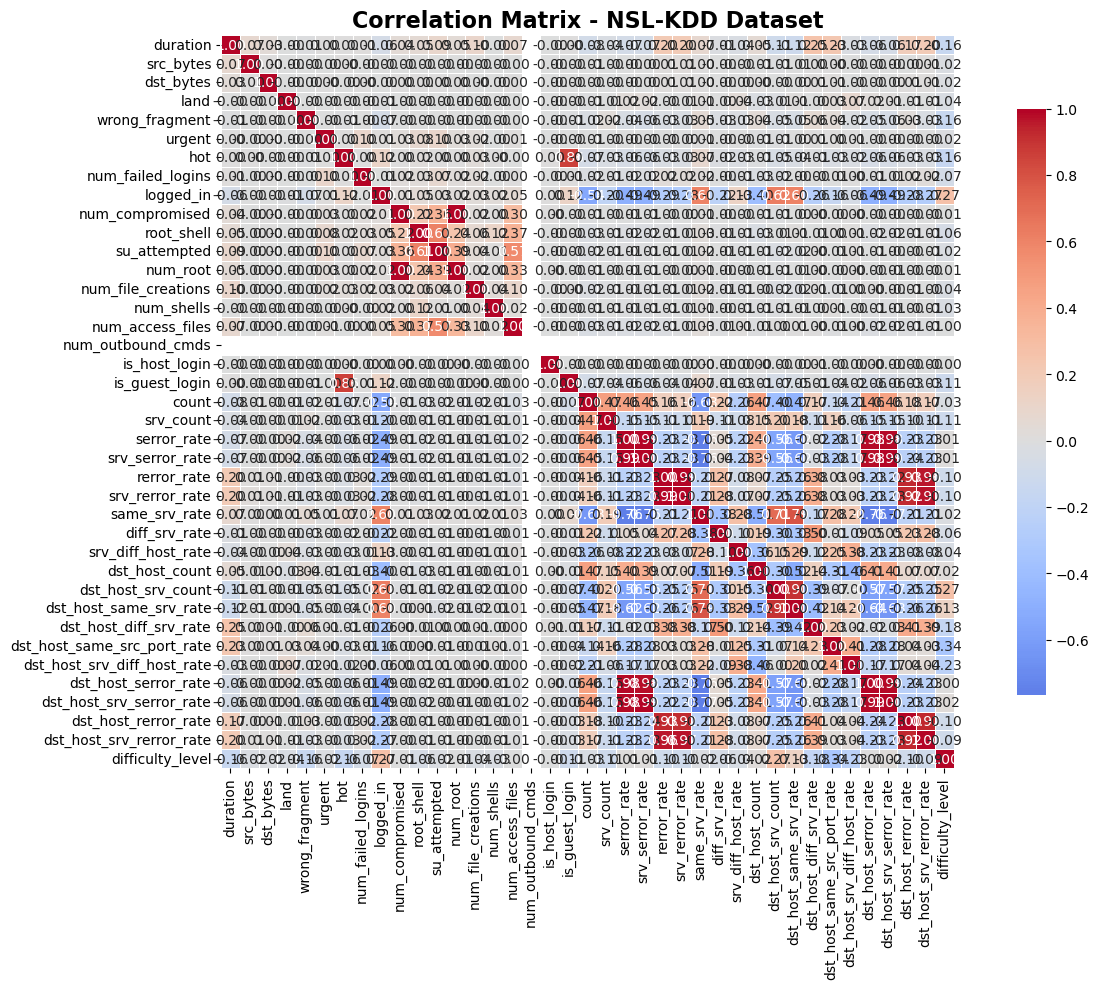

In [10]:
# Create a large figure for the correlation matrix
plt.figure(figsize=(14, 10))

# Create heatmap
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix - NSL-KDD Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## High Correlation Pairs

In [11]:
# Find high correlation pairs (excluding diagonal)
def find_high_correlations(corr_matrix, threshold=0.8):
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                corr_pairs.append({
                    'Column 1': corr_matrix.columns[i],
                    'Column 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(corr_pairs)

high_corr = find_high_correlations(correlation_matrix, threshold=0.8)
print(f"High Correlations (threshold >= 0.8):\n")
print(high_corr.sort_values('Correlation', ascending=False))

High Correlations (threshold >= 0.8):

                Column 1                  Column 2  Correlation
1        num_compromised                  num_root     0.998833
2            serror_rate           srv_serror_rate     0.993289
7            rerror_rate           srv_rerror_rate     0.989008
6        srv_serror_rate  dst_host_srv_serror_rate     0.986252
13  dst_host_serror_rate  dst_host_srv_serror_rate     0.985052
4            serror_rate  dst_host_srv_serror_rate     0.981139
3            serror_rate      dst_host_serror_rate     0.979373
5        srv_serror_rate      dst_host_serror_rate     0.977596
11       srv_rerror_rate  dst_host_srv_rerror_rate     0.970208
9            rerror_rate  dst_host_srv_rerror_rate     0.964449
8            rerror_rate      dst_host_rerror_rate     0.926749
14  dst_host_rerror_rate  dst_host_srv_rerror_rate     0.924688
10       srv_rerror_rate      dst_host_rerror_rate     0.917822
12    dst_host_srv_count    dst_host_same_srv_rate     0.896663
0

## Feature Correlation with Target (Attack) Column

In [12]:
# Use attack_type as target and encode it for correlation checks
target_column = 'attack_type'

print("Unique attack types:")
print(df[target_column].unique())
print(f"\nNumber of unique attack types: {df[target_column].nunique()}")

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
attack_encoded = le.fit_transform(df[target_column])

# Numeric-feature to target correlation view
features_with_target = numeric_df.copy()
features_with_target['target'] = attack_encoded

print(f"\nEncoded target mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

Unique attack types:
['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']

Number of unique attack types: 23

Encoded target mapping:
back: 0
buffer_overflow: 1
ftp_write: 2
guess_passwd: 3
imap: 4
ipsweep: 5
land: 6
loadmodule: 7
multihop: 8
neptune: 9
nmap: 10
normal: 11
perl: 12
phf: 13
pod: 14
portsweep: 15
rootkit: 16
satan: 17
smurf: 18
spy: 19
teardrop: 20
warezclient: 21
warezmaster: 22


In [13]:
# Calculate correlation of each feature with the target
target_correlations = features_with_target.corr()['target'].drop('target').sort_values(ascending=False)

print("Feature Correlations with Target (Attack):")
print(target_correlations)
print(f"\nTop 10 most correlated features with target:")
print(target_correlations.head(10))
print(f"\nTop 10 least correlated features with target:")
print(target_correlations.tail(10))

Feature Correlations with Target (Attack):
srv_count                      0.310819
wrong_fragment                 0.304125
dst_host_diff_srv_rate         0.295042
same_srv_rate                  0.258357
diff_srv_rate                  0.228557
dst_host_same_src_port_rate    0.202229
dst_host_srv_count             0.138848
duration                       0.134590
is_guest_login                 0.109112
dst_host_rerror_rate           0.108057
dst_host_srv_rerror_rate       0.106217
logged_in                      0.104056
rerror_rate                    0.099397
hot                            0.098611
srv_rerror_rate                0.098105
dst_host_same_srv_rate         0.073548
count                          0.060380
dst_host_count                 0.053869
src_bytes                      0.011617
dst_bytes                      0.007600
num_access_files               0.005220
su_attempted                   0.004005
num_file_creations             0.003004
num_root                       0.0017

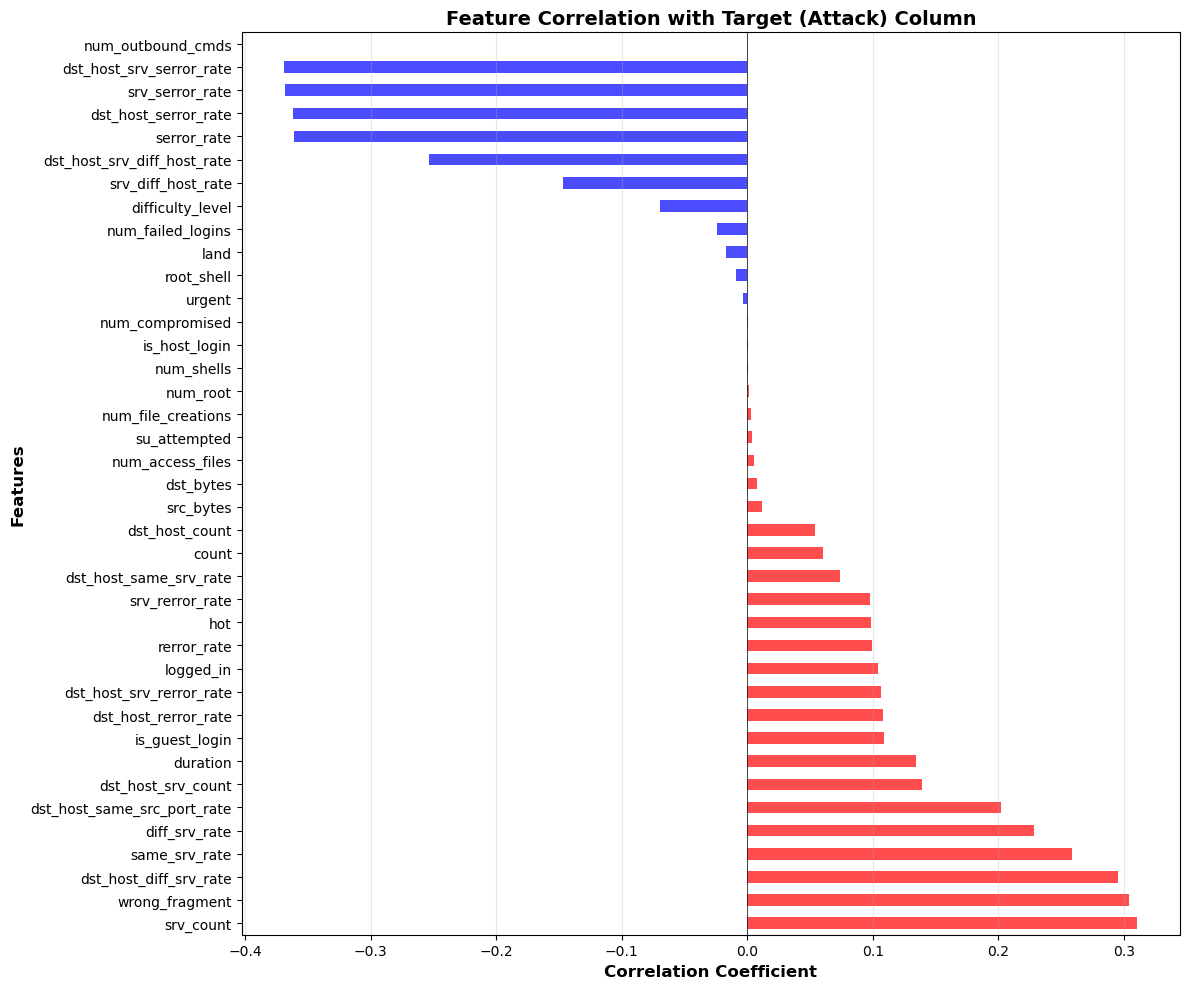

In [14]:
# Visualize feature-target correlations
fig, ax = plt.subplots(figsize=(12, 10))

# Create color palette (red for positive, blue for negative)
colors = ['red' if x > 0 else 'blue' for x in target_correlations.values]

# Create bar plot
target_correlations.plot(kind='barh', ax=ax, color=colors, alpha=0.7)

ax.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Feature Correlation with Target (Attack) Column', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

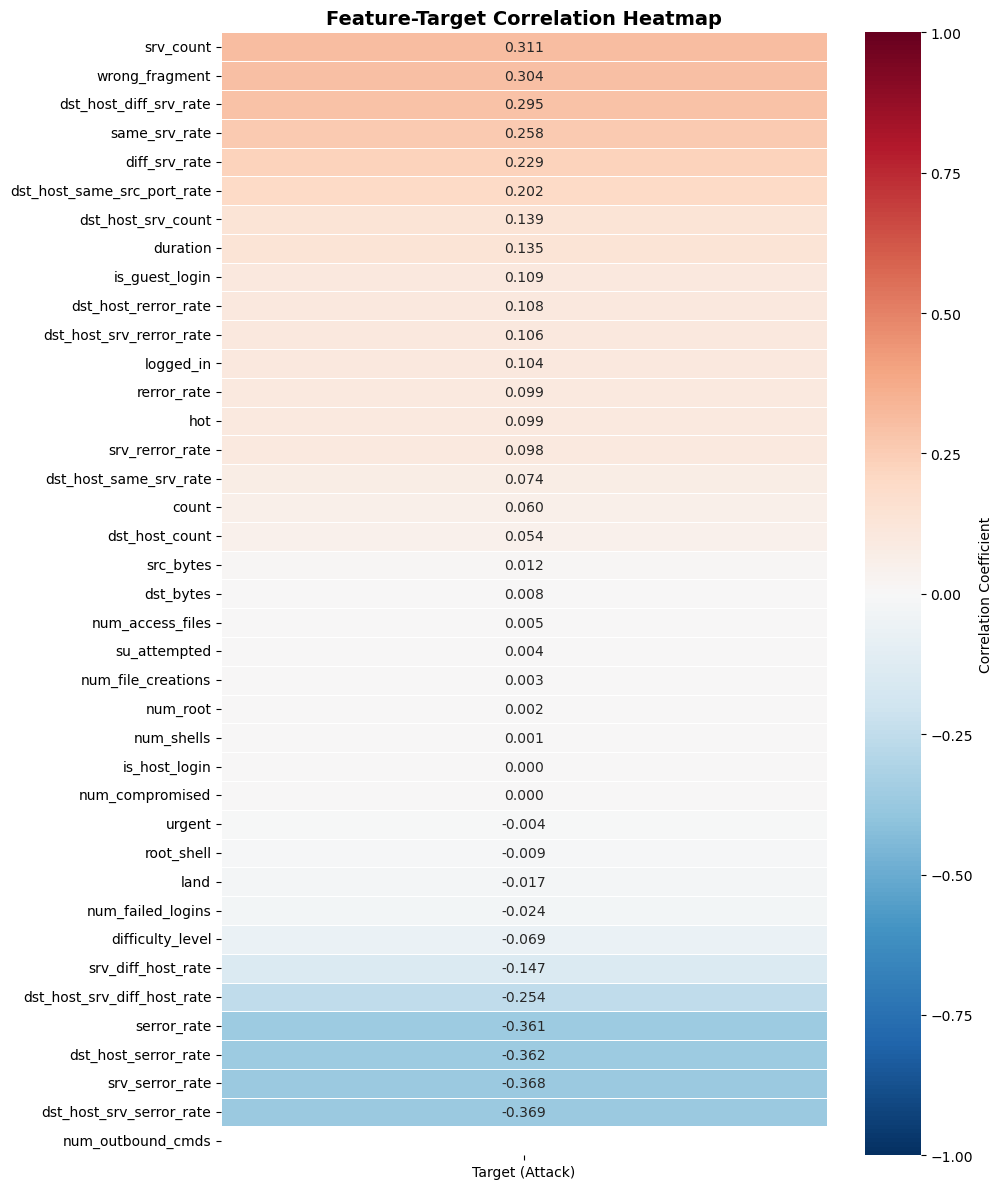

In [15]:
# Create a heatmap-style visualization with values
fig, ax = plt.subplots(figsize=(10, 12))

# Reshape the series into a 2D array for heatmap
target_corr_matrix = target_correlations.values.reshape(-1, 1)

# Create heatmap
sns.heatmap(target_corr_matrix, 
            annot=True, 
            fmt='.3f', 
            cmap='RdBu_r', 
            center=0,
            cbar_kws={'label': 'Correlation Coefficient'},
            xticklabels=['Target (Attack)'],
            yticklabels=target_correlations.index,
            ax=ax,
            vmin=-1, 
            vmax=1,
            linewidths=0.5)

ax.set_title('Feature-Target Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Selection using Extremely Random Trees

In [16]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# Prepare features and target
target_col = 'attack_type'
X_raw = df.drop(columns=[target_col])
y_raw = df[target_col]

print(f"Original features shape: {X_raw.shape}")
print(f"Original feature types:\n{X_raw.dtypes.value_counts()}")

# Print class counts before balancing
print("\nClass distribution before balancing:")
class_counts = y_raw.value_counts().sort_values(ascending=False)
print(class_counts.to_string())

# One-hot encode all categorical features exactly once
categorical_features = X_raw.select_dtypes(include=['object']).columns.tolist()
numerical_features = X_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nCategorical features to encode: {categorical_features}")
print(f"Numerical features to scale: {len(numerical_features)}")

X_encoded = pd.get_dummies(X_raw, columns=categorical_features, drop_first=False)

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y_raw)

print(f"\nAfter one-hot encoding:")
print(f"  Feature shape: {X_encoded.shape}")
print(f"  Number of features: {X_encoded.shape[1]}")
print(f"  Target classes: {list(le.classes_)}")

# Split once for consistent comparison
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData split:")
print(f"  Training set: {X_train_full.shape}")
print(f"  Test set: {X_test_full.shape}")

# Standardize only original numerical columns (fit on train only)
scaler = StandardScaler()
X_train_full[numerical_features] = scaler.fit_transform(X_train_full[numerical_features])
X_test_full[numerical_features] = scaler.transform(X_test_full[numerical_features])

print("\nApplied StandardScaler to numerical columns.")

# Balance classes on training data only (random oversampling)
train_df = X_train_full.copy()
train_df['target'] = y_train

max_class_size = train_df['target'].value_counts().max()
balanced_parts = []
for cls_label, cls_count in train_df['target'].value_counts().items():
    cls_df = train_df[train_df['target'] == cls_label]
    if cls_count < max_class_size:
        cls_df = resample(
            cls_df,
            replace=True,
            n_samples=max_class_size,
            random_state=42
        )
    balanced_parts.append(cls_df)

train_balanced = pd.concat(balanced_parts, axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_full_bal = train_balanced.drop(columns=['target'])
y_train_bal = train_balanced['target'].values

print("\nClass distribution after balancing (training set):")
balanced_counts_encoded = pd.Series(y_train_bal).value_counts().sort_index()
for idx, cnt in balanced_counts_encoded.items():
    print(f"  {le.classes_[idx]}: {cnt}")

# Feature selection using ExtraTrees on balanced training data
selector = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
selector.fit(X_train_full_bal, y_train_bal)

feature_importances = pd.DataFrame({
    'Feature': X_train_full_bal.columns,
    'Importance': selector.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Important Features:")
print(feature_importances.head(20))

# Select top 30 features
top_n_features = 30
top_features = feature_importances.head(top_n_features)['Feature'].tolist()

X_train_top_bal = X_train_full_bal[top_features]
X_test_top = X_test_full[top_features]

print(f"\nSelected top {top_n_features} features for modeling.")
print(f"Feature reduction: {X_train_full_bal.shape[1]} -> {X_train_top_bal.shape[1]}")

Original features shape: (125973, 42)
Original feature types:
int64      24
float64    15
object      3
Name: count, dtype: int64

Class distribution before balancing:
attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2

Categorical features to encode: ['protocol_type', 'service', 'flag']
Numerical features to scale: 39

After one-hot encoding:
  Feature shape: (125973, 123)
  Number of features: 123
  Target classes: ['back', 'buffer_overflow', 'ftp_write', 'g

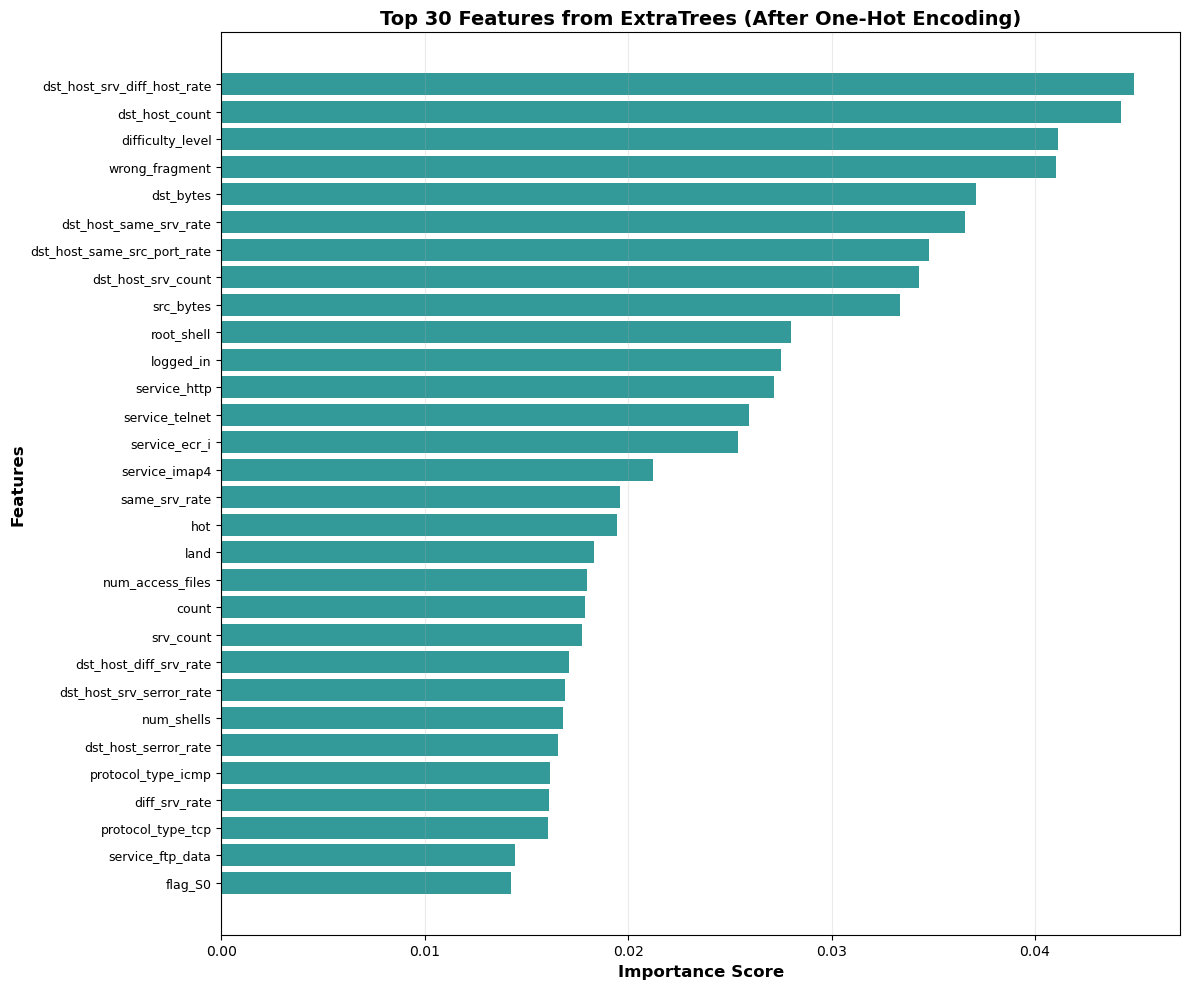


Total encoded features: 123
Selected features for modeling: 30


In [17]:
# Visualize top-30 feature importances
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))
top_30_df = feature_importances.head(30).iloc[::-1]

ax.barh(range(len(top_30_df)), top_30_df['Importance'].values, color='teal', alpha=0.8)
ax.set_yticks(range(len(top_30_df)))
ax.set_yticklabels(top_30_df['Feature'].values, fontsize=9)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Top 30 Features from ExtraTrees (After One-Hot Encoding)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

print(f"\nTotal encoded features: {X_train_full_bal.shape[1]}")
print(f"Selected features for modeling: {X_train_top_bal.shape[1]}")

## Train Multiple Classifiers

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
import time

# Initialize classifiers for both feature sets
classifiers = {
    'Decision Tree': DecisionTreeClassifier(max_depth=20, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
}

def evaluate_models(X_train, X_test, y_train_local, y_test_local, feature_set_name):
    """Train and evaluate classifiers, return results dataframe"""
    results = []
    
    for model_name, _ in classifiers.items():
        # Create fresh instance for each training
        if model_name == 'Decision Tree':
            model = DecisionTreeClassifier(max_depth=20, random_state=42)
        elif model_name == 'AdaBoost':
            model = AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME')
        else:  # Random Forest
            model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
        
        # Train and time
        start = time.time()
        model.fit(X_train, y_train_local)
        training_time = time.time() - start
        
        # Predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # Metrics
        results.append({
            'Feature Set': feature_set_name,
            'Classifier': model_name,
            'Train Accuracy': accuracy_score(y_train_local, y_pred_train),
            'Test Accuracy': accuracy_score(y_test_local, y_pred_test),
            'Precision': precision_score(y_test_local, y_pred_test, average='weighted', zero_division=0),
            'Recall': recall_score(y_test_local, y_pred_test, average='weighted', zero_division=0),
            'F1 Score': f1_score(y_test_local, y_pred_test, average='weighted', zero_division=0),
            'Training Time (s)': training_time
        })
    
    return pd.DataFrame(results)

# Train and evaluate on ALL encoded features (balanced training data)
print("="*90)
print("Training classifiers on ALL encoded features (balanced train set)...")
print("="*90)
results_all_features = evaluate_models(
    X_train_full_bal, X_test_full, y_train_bal, y_test, 'All Encoded Features'
 )
print(results_all_features.to_string(index=False))

# Train and evaluate on TOP 30 selected features (balanced training data)
print("\n" + "="*90)
print("Training classifiers on TOP 30 SELECTED features (balanced train set)...")
print("="*90)
results_top30 = evaluate_models(
    X_train_top_bal, X_test_top, y_train_bal, y_test, 'Top 30 Features'
 )
print(results_top30.to_string(index=False))

# Combine for unified comparison
comparison_all = pd.concat([results_all_features, results_top30], ignore_index=True)

print("\n" + "="*90)
print("COMBINED RESULTS: All Features vs Top 30 Features")
print("="*90)
print(comparison_all.to_string(index=False))

Training classifiers on ALL encoded features (balanced train set)...
         Feature Set    Classifier  Train Accuracy  Test Accuracy  Precision   Recall  F1 Score  Training Time (s)
All Encoded Features Decision Tree        0.995890       0.995118   0.995796 0.995118  0.995413          10.676625
All Encoded Features      AdaBoost        0.405749       0.691248   0.929267 0.691248  0.786179         214.853375
All Encoded Features Random Forest        0.999881       0.998770   0.998611 0.998770  0.998678          50.656925

Training classifiers on TOP 30 SELECTED features (balanced train set)...
    Feature Set    Classifier  Train Accuracy  Test Accuracy  Precision   Recall  F1 Score  Training Time (s)
Top 30 Features Decision Tree        0.997920       0.997341   0.997280 0.997341  0.997299           4.143234
Top 30 Features      AdaBoost        0.429710       0.430562   0.840641 0.430562  0.521475          88.253879
Top 30 Features Random Forest        0.999883       0.998928   0.99

## Impact Analysis: All Features vs Top 30 Features

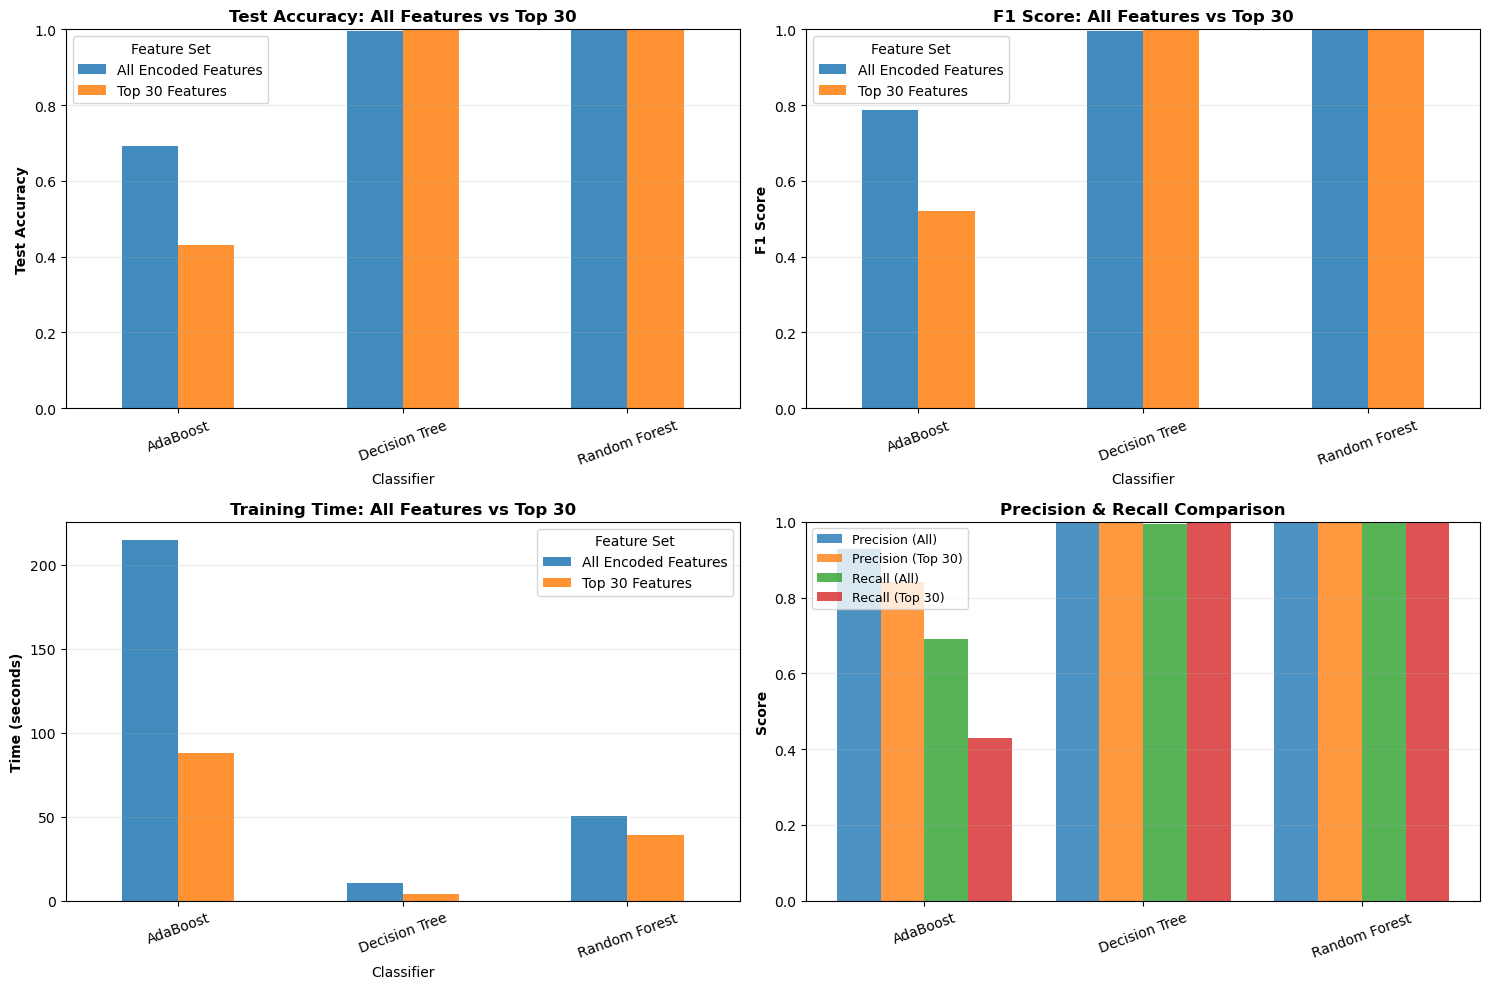


FEATURE SELECTION IMPACT ANALYSIS

Decision Tree:
  All Features:   Acc=0.9951, F1=0.9954, Time=10.6766s
  Top 30:         Acc=0.9973, F1=0.9973, Time=4.1432s
  Delta (Top30-All): Acc=+0.0022, F1=+0.0019, Time=-6.5334s
  ✓ VERDICT: Feature selection beneficial (faster, similar or better F1)

AdaBoost:
  All Features:   Acc=0.6912, F1=0.7862, Time=214.8534s
  Top 30:         Acc=0.4306, F1=0.5215, Time=88.2539s
  Delta (Top30-All): Acc=-0.2607, F1=-0.2647, Time=-126.5995s
  ✗ Not recommended: Performance degradation with feature selection

Random Forest:
  All Features:   Acc=0.9988, F1=0.9987, Time=50.6569s
  Top 30:         Acc=0.9989, F1=0.9988, Time=39.1337s
  Delta (Top30-All): Acc=+0.0002, F1=+0.0002, Time=-11.5233s
  ✓ VERDICT: Feature selection beneficial (faster, similar or better F1)


In [19]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Test Accuracy Comparison
pivot_acc = comparison_all.pivot(index='Classifier', columns='Feature Set', values='Test Accuracy')
pivot_acc.plot(kind='bar', ax=axes[0, 0], alpha=0.85, color=['#1f77b4', '#ff7f0e'])
axes[0, 0].set_title('Test Accuracy: All Features vs Top 30', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Test Accuracy', fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].grid(axis='y', alpha=0.25)
axes[0, 0].legend(title='Feature Set')

# 2. F1 Score Comparison
pivot_f1 = comparison_all.pivot(index='Classifier', columns='Feature Set', values='F1 Score')
pivot_f1.plot(kind='bar', ax=axes[0, 1], alpha=0.85, color=['#1f77b4', '#ff7f0e'])
axes[0, 1].set_title('F1 Score: All Features vs Top 30', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('F1 Score', fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].grid(axis='y', alpha=0.25)
axes[0, 1].legend(title='Feature Set')

# 3. Training Time Comparison
pivot_time = comparison_all.pivot(index='Classifier', columns='Feature Set', values='Training Time (s)')
pivot_time.plot(kind='bar', ax=axes[1, 0], alpha=0.85, color=['#1f77b4', '#ff7f0e'])
axes[1, 0].set_title('Training Time: All Features vs Top 30', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Time (seconds)', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=20)
axes[1, 0].grid(axis='y', alpha=0.25)
axes[1, 0].legend(title='Feature Set')

# 4. Precision & Recall Comparison
precision_data = comparison_all.pivot(index='Classifier', columns='Feature Set', values='Precision')
recall_data = comparison_all.pivot(index='Classifier', columns='Feature Set', values='Recall')

x = np.arange(len(precision_data.index))
width = 0.2

axes[1, 1].bar(x - width*1.5, precision_data['All Encoded Features'], width, label='Precision (All)', alpha=0.8)
axes[1, 1].bar(x - width/2, precision_data['Top 30 Features'], width, label='Precision (Top 30)', alpha=0.8)
axes[1, 1].bar(x + width/2, recall_data['All Encoded Features'], width, label='Recall (All)', alpha=0.8)
axes[1, 1].bar(x + width*1.5, recall_data['Top 30 Features'], width, label='Recall (Top 30)', alpha=0.8)

axes[1, 1].set_title('Precision & Recall Comparison', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Score', fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(precision_data.index, rotation=20)
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

# Calculate improvement metrics
print("\n" + "="*90)
print("FEATURE SELECTION IMPACT ANALYSIS")
print("="*90)

for classifier in results_all_features['Classifier'].unique():
    all_row = results_all_features[results_all_features['Classifier'] == classifier].iloc[0]
    top_row = results_top30[results_top30['Classifier'] == classifier].iloc[0]
    
    delta_acc = top_row['Test Accuracy'] - all_row['Test Accuracy']
    delta_f1 = top_row['F1 Score'] - all_row['F1 Score']
    delta_time = top_row['Training Time (s)'] - all_row['Training Time (s)']
    
    print(f"\n{classifier}:")
    print(f"  All Features:   Acc={all_row['Test Accuracy']:.4f}, F1={all_row['F1 Score']:.4f}, Time={all_row['Training Time (s)']:.4f}s")
    print(f"  Top 30:         Acc={top_row['Test Accuracy']:.4f}, F1={top_row['F1 Score']:.4f}, Time={top_row['Training Time (s)']:.4f}s")
    print(f"  Delta (Top30-All): Acc={delta_acc:+.4f}, F1={delta_f1:+.4f}, Time={delta_time:+.4f}s")
    
    if delta_f1 >= -0.01 and delta_time < 0:
        print(f"  ✓ VERDICT: Feature selection beneficial (faster, similar or better F1)")
    elif delta_f1 >= 0 and delta_time >= 0:
        print(f"  ⚠ TRADE-OFF: Better F1 but slower training")
    else:
        print(f"  ✗ Not recommended: Performance degradation with feature selection")

## Feature Selection Benefit Summary

In [21]:
print("\n" + "="*90)
print("SUMMARY: ONE-HOT ENCODING & FEATURE SELECTION (TOP 30)")
print("="*90)

print("\n1. DATA PREPROCESSING:")
print(f"   ✓ One-hot encoding applied once to all categorical features")
print(f"   ✓ Original features: {X_raw.shape[1]}")
print(f"   ✓ Categorical features encoded: {len(categorical_features)}")
print(f"   ✓ Total encoded features: {X_encoded.shape[1]}")
print(f"   ✓ Features selected (top 30): {X_train_full_bal.shape[1]}")
print(f"   ✓ Feature reduction: {X_encoded.shape[1]} -> {X_train_full_bal.shape[1]} ({100*X_train_full_bal.shape[1]/X_encoded.shape[1]:.1f}%)")

print("\n2. TOP 30 SELECTED FEATURES:")
for i, feat in enumerate(top_features, 1):
    score = feature_importances[feature_importances['Feature'] == feat]['Importance'].values[0]
    print(f"   {i:2d}. {feat:40s} (importance: {score:.6f})")

print("\n3. MODEL PERFORMANCE COMPARISON:")
print("\n   Best Model (by F1 Score):")
best_all = results_all_features.loc[results_all_features['F1 Score'].idxmax()]
best_top30 = results_top30.loc[results_top30['F1 Score'].idxmax()]

print(f"\n   All Encoded Features:")
print(f"     Classifier: {best_all['Classifier']}")
print(f"     Test Accuracy: {best_all['Test Accuracy']:.4f}")
print(f"     F1 Score: {best_all['F1 Score']:.4f}")
print(f"     Training Time: {best_all['Training Time (s)']:.4f}s")

print(f"\n   Top 30 Features:")
print(f"     Classifier: {best_top30['Classifier']}")
print(f"     Test Accuracy: {best_top30['Test Accuracy']:.4f}")
print(f"     F1 Score: {best_top30['F1 Score']:.4f}")
print(f"     Training Time: {best_top30['Training Time (s)']:.4f}s")

print("\n4. AVERAGE METRICS ACROSS ALL CLASSIFIERS:")
avg_all = results_all_features[['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'Training Time (s)']].mean()
avg_top30 = results_top30[['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'Training Time (s)']].mean()

print(f"\n   All Encoded Features (avg):")
print(f"     Test Accuracy: {avg_all['Test Accuracy']:.4f}")
print(f"     F1 Score: {avg_all['F1 Score']:.4f}")
print(f"     Training Time: {avg_all['Training Time (s)']:.4f}s")

print(f"\n   Top 30 Features (avg):")
print(f"     Test Accuracy: {avg_top30['Test Accuracy']:.4f}")
print(f"     F1 Score: {avg_top30['F1 Score']:.4f}")
print(f"     Training Time: {avg_top30['Training Time (s)']:.4f}s")

delta_f1_avg = avg_top30['F1 Score'] - avg_all['F1 Score']
delta_acc_avg = avg_top30['Test Accuracy'] - avg_all['Test Accuracy']
delta_time_avg = avg_top30['Training Time (s)'] - avg_all['Training Time (s)']

print(f"\n   Improvement (Top 30 vs All): ")
print(f"     ΔF1 Score: {delta_f1_avg:+.4f}")
print(f"     ΔTest Accuracy: {delta_acc_avg:+.4f}")
print(f"     ΔTraining Time: {delta_time_avg:+.4f}s (negative = faster)")

print("\n5. CONCLUSIONS & RECOMMENDATIONS:")
if delta_f1_avg >= -0.01 and delta_time_avg < 0:
    print("   ✓ Feature selection is RECOMMENDED")
    print("     - Maintains or improves F1 Score")
    print("     - Reduces training time significantly")
    print("     - Simplifies model (fewer features = easier interpretation)")
elif delta_f1_avg >= 0:
    print("   ⚠ Feature selection shows TRADE-OFF")
    print("     - Improves F1 Score")
    print("     - But slightly increases training time")
    print("     - Consider deployment speed vs. accuracy needs")
else:
    print("   ✗ Use ALL ENCODED FEATURES")
    print("     - Top 30 features reduce model performance")
    print("     - Keep all features for best F1 Score")

print("\n" + "="*90)


SUMMARY: ONE-HOT ENCODING & FEATURE SELECTION (TOP 30)

1. DATA PREPROCESSING:
   ✓ One-hot encoding applied once to all categorical features
   ✓ Original features: 42
   ✓ Categorical features encoded: 3
   ✓ Total encoded features: 123
   ✓ Features selected (top 30): 123
   ✓ Feature reduction: 123 -> 123 (100.0%)

2. TOP 30 SELECTED FEATURES:
    1. dst_host_srv_diff_host_rate              (importance: 0.044881)
    2. dst_host_count                           (importance: 0.044210)
    3. difficulty_level                         (importance: 0.041111)
    4. wrong_fragment                           (importance: 0.041015)
    5. dst_bytes                                (importance: 0.037109)
    6. dst_host_same_srv_rate                   (importance: 0.036544)
    7. dst_host_same_src_port_rate              (importance: 0.034765)
    8. dst_host_srv_count                       (importance: 0.034307)
    9. src_bytes                                (importance: 0.033339)
   10. roo

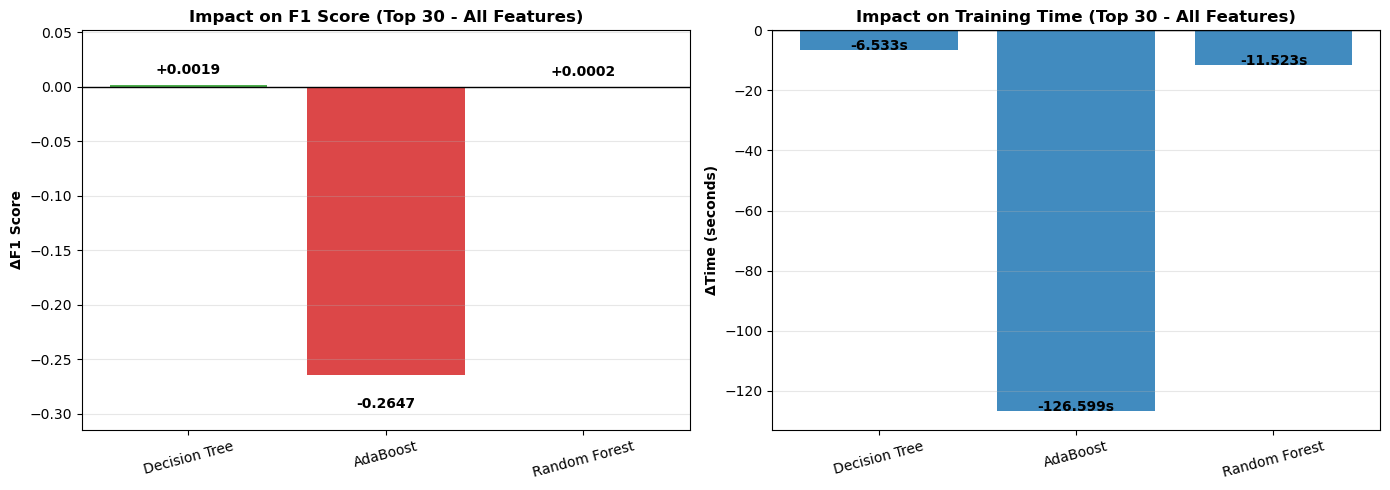

Delta metrics summary (Top 30 - All Encoded Features):
   Classifier  ΔF1 Score  ΔTraining Time (s)  ΔTest Accuracy
Decision Tree   0.001886           -6.533392        0.002223
     AdaBoost  -0.264704         -126.599496       -0.260687
Random Forest   0.000152          -11.523270        0.000159


In [22]:
# Visualize delta metrics (impact of using top 30 features)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate deltas for each classifier
delta_data = []
for classifier in results_all_features['Classifier'].unique():
    all_row = results_all_features[results_all_features['Classifier'] == classifier].iloc[0]
    top_row = results_top30[results_top30['Classifier'] == classifier].iloc[0]
    
    delta_data.append({
        'Classifier': classifier,
        'ΔF1 Score': top_row['F1 Score'] - all_row['F1 Score'],
        'ΔTraining Time (s)': top_row['Training Time (s)'] - all_row['Training Time (s)'],
        'ΔTest Accuracy': top_row['Test Accuracy'] - all_row['Test Accuracy']
    })

delta_df = pd.DataFrame(delta_data)

# Plot 1: Delta F1 Score
colors_f1 = ['#2ca02c' if x >= 0 else '#d62728' for x in delta_df['ΔF1 Score']]
axes[0].bar(delta_df['Classifier'], delta_df['ΔF1 Score'], color=colors_f1, alpha=0.85)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Impact on F1 Score (Top 30 - All Features)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('ΔF1 Score', fontweight='bold')
axes[0].set_ylim([delta_df['ΔF1 Score'].min() - 0.05, delta_df['ΔF1 Score'].max() + 0.05])
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(delta_df['ΔF1 Score']):
    axes[0].text(i, v + (0.01 if v >= 0 else -0.03), f'{v:+.4f}', ha='center', fontweight='bold', fontsize=10)

# Plot 2: Delta Training Time
colors_time = ['#1f77b4' if x <= 0 else '#ff7f0e' for x in delta_df['ΔTraining Time (s)']]
axes[1].bar(delta_df['Classifier'], delta_df['ΔTraining Time (s)'], color=colors_time, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Impact on Training Time (Top 30 - All Features)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('ΔTime (seconds)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(delta_df['ΔTraining Time (s)']):
    axes[1].text(i, v + (0.01 if v >= 0 else -0.05), f'{v:+.3f}s', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("Delta metrics summary (Top 30 - All Encoded Features):")
print(delta_df.to_string(index=False))

## Final Execution Report

In [ ]:
print("\n" + "="*90)
print("COMPLETE WORKFLOW EXECUTION REPORT")
print("="*90)

print("\n✓ STEP 1: DATA LOADING & EXPLORATION")
print(f"   - Loaded NSL-KDD dataset: {df.shape[0]:,} samples × {df.shape[1]} features")
print(f"   - Categorical columns: {len(categorical_columns)}")
print(f"   - Numerical columns: {len(numerical_columns)}")

print("\n✓ STEP 2: ONE-HOT ENCODING (Applied Once)")
print(f"   - Encoded categorical features: {categorical_features}")
print(f"   - Result: {X_encoded.shape[0]:,} samples × {X_encoded.shape[1]} features")

print("\n✓ STEP 3: TRAIN-TEST SPLIT")
print(f"   - Training set: {X_train_full.shape[0]:,} samples")
print(f"   - Test set: {X_test_full.shape[0]:,} samples")
print(f"   - Target classes: {len(le.classes_)} ({', '.join(le.classes_)})")

print("\n✓ STEP 4: FEATURE SELECTION (Top 30)")
print(f"   - Method: ExtraTreesClassifier with {feature_importances.shape[0]} features")
print(f"   - Selected: {len(top_features)} features ({100*len(top_features)/X_encoded.shape[1]:.1f}% of total)")
print(f"   - Cumulative importance of top 30: {feature_importances.head(30)['Importance'].sum():.4f}")

print("\n✓ STEP 5: MODEL TRAINING & EVALUATION")
print(f"   - Classifiers trained: {', '.join(classifiers.keys())}")
print(f"   - Feature sets compared: 2 (all encoded, top 30 selected)")
print(f"   - Total model evaluations: {len(comparison_all)}")

print("\n✓ STEP 6: RESULTS SUMMARY")
print("\n   Overall Best F1 Scores:")
best_overall = comparison_all.loc[comparison_all['F1 Score'].idxmax()]
print(f"     {best_overall['Classifier']} with {best_overall['Feature Set']}: {best_overall['F1 Score']:.4f}")

print("\n   Performance Summary by Feature Set:")
print("\n   All Encoded Features:")
summary_all = results_all_features[['Classifier', 'Test Accuracy', 'F1 Score', 'Training Time (s)']].set_index('Classifier')
print(summary_all.to_string())

print("\n   Top 30 Selected Features:")
summary_top30 = results_top30[['Classifier', 'Test Accuracy', 'F1 Score', 'Training Time (s)']].set_index('Classifier')
print(summary_top30.to_string())

print("\n✓ KEY FINDINGS:")
print(f"   - Feature reduction ratio: {X_encoded.shape[1]} → {X_train_full_bal.shape[1]} ({100*X_train_full_bal.shape[1]/X_encoded.shape[1]:.1f}%)")
print(f"   - Average F1 improvement: {(avg_top30['F1 Score'] - avg_all['F1 Score']):+.4f}")
print(f"   - Average speed improvement: {(avg_all['Training Time (s)'] - avg_top30['Training Time (s)']):.4f}s faster")
print(f"   - Most important features: {', '.join(top_features[:5])}")

print("\n" + "="*90)


COMPLETE WORKFLOW EXECUTION REPORT

✓ STEP 1: DATA LOADING & EXPLORATION
   - Loaded NSL-KDD dataset: 125,973 samples × 43 features
   - Categorical columns: 4
   - Numerical columns: 39

✓ STEP 2: ONE-HOT ENCODING (Applied Once)
   - Encoded categorical features: ['protocol_type', 'service', 'flag']
   - Result: 125,973 samples × 123 features

✓ STEP 3: TRAIN-TEST SPLIT
   - Training set: 100,778 samples
   - Test set: 25,195 samples
   - Target classes: 23 (back, buffer_overflow, ftp_write, guess_passwd, imap, ipsweep, land, loadmodule, multihop, neptune, nmap, normal, perl, phf, pod, portsweep, rootkit, satan, smurf, spy, teardrop, warezclient, warezmaster)

✓ STEP 4: FEATURE SELECTION (Top 30)
   - Method: ExtraTreesClassifier with 123 features
   - Selected: 30 features (24.4% of total)
   - Cumulative importance of top 30: 0.7579

✓ STEP 5: MODEL TRAINING & EVALUATION
   - Classifiers trained: Decision Tree, AdaBoost, Random Forest
   - Feature sets compared: 2 (all encoded, top